In [3]:
!pip install -q transformers sentence-transformers faiss-cpu bitsandbytes accelerate datasets pymupdf pandas numpy matplotlib scikit-learn langchain-community torch

import torch
import sys
import os
import gc
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Compute Capability: {torch.cuda.get_device_capability(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("WARNING: CUDA is not available. BitsAndBytes and GPU acceleration will be disabled.")
print("="*60)

def get_vram_usage():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved = torch.cuda.memory_reserved() / (1024 ** 2)
        print(f"[VRAM Monitor] Allocated: {allocated:.2f} MB | Reserved: {reserved:.2f} MB")
        return allocated, reserved
    else:
        print("[VRAM Monitor] CUDA is not active. VRAM tracking unavailable.")
        return 0.0, 0.0

def flush_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("[Memory Flush] GPU memory cache cleared.")
    else:
        print("[Memory Flush] CPU garbage collected.")

# Initial check
get_vram_usage()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
[VRAM Monitor] CUDA is not active. VRAM tracking unavailable.


(0.0, 0.0)

In [4]:
documents = [
    {
        "id": "doc_hr_01",
        "category": "HR Policies",
        "title": "Annual Leave and Time-Off Policy",
        "content": "Employees are entitled to 25 days of paid annual leave per calendar year. Vacation requests must be submitted through the HR Portal at least 14 days in advance and approved by the direct manager. Unused leave up to a maximum of 5 days can be carried forward to the next calendar year, but must be utilized within the first quarter (by March 31st). Failure to use the carried-over leave by this deadline results in automatic forfeiture. Compassionate leave is granted up to 5 days for immediate family members.",
        "language": "English"
    },
    {
        "id": "doc_hr_02",
        "category": "HR Policies",
        "title": "Remote Work and Flexible Hours Guideline",
        "content": "Our remote work framework supports a hybrid model requiring at least 2 days of in-office presence per week. Core collaboration hours are set between 10:00 AM and 4:00 PM EST, during which all employees must be reachable via corporate Slack and email. A home office stipend of $500 is provided as a one-time reimbursement for ergonomic chairs, monitors, and high-speed internet setup. Expense reports for ergonomic equipment must be submitted within 60 days of purchase with valid receipts.",
        "language": "English"
    },
    {
        "id": "doc_it_01",
        "category": "IT Support",
        "title": "Corporate VPN Connection Troubleshooting Guide",
        "content": "To connect to the corporate network remotely, use the Cisco AnyConnect client. Enter the gateway address 'vpn.enterprise.global.com'. Authentication requires your standard active directory username and password, followed by a multi-factor authentication (MFA) prompt via Duo Mobile. If you experience error 'Gateway Unreachable', disconnect from your local Wi-Fi, toggle airplane mode on and off, restart your router, and ensure DNS settings are configured to automatic DHCP. If the problem persists, flush your DNS cache by running 'ipconfig /flushdns' in Command Prompt.",
        "language": "English"
    },
    {
        "id": "doc_it_02",
        "category": "IT Support",
        "title": "Self-Service Password Reset Policy",
        "content": "Corporate passwords expire every 90 days. Passwords must be at least 14 characters long and include uppercase letters, lowercase letters, numbers, and at least two special characters (e.g., !, @, #, $, %, ^, &). You cannot reuse any of your last 5 passwords. If your account is locked due to 5 consecutive incorrect attempts, it will remain locked for 30 minutes. You can perform an immediate unlock and password reset by visiting the password portal at 'https://password.enterprise.global.com' and verifying your identity via SMS code.",
        "language": "English"
    },
    {
        "id": "doc_ob_01",
        "category": "Onboarding",
        "title": "First Week Checklist for New Joiners",
        "content": "Welcome to the team! On Day 1, complete your I-9 verification and collect your laptop from the IT desk on the 3rd floor. On Day 2, log into Workday to configure your direct deposit bank details and select your health benefits. On Day 3, complete the mandatory compliance training modules: 'Information Security Fundamentals' and 'Code of Conduct'. On Day 4, schedule a 1-on-1 introductory meeting with your manager and your designated peer buddy. On Day 5, join the weekly team sync and introduce yourself.",
        "language": "English"
    },
    {
        "id": "doc_ob_02",
        "category": "Onboarding",
        "title": "Engineering Team Onboarding & SOP",
        "content": "Engineering team members must clone repositories from the enterprise GitLab organization. Code reviews are mandatory for all pull requests, requiring approval from at least two peers before merging. The main branch is protected; developers must work on feature branches named using the pattern 'feature/TICKET-ID-description'. We run automated CI/CD pipelines that execute lints, unit tests, and integration checks on every commit. Deployments are executed automatically to staging, and manually to production via Jenkins after QA sign-off.",
        "language": "English"
    },
    {
        "id": "doc_comp_01",
        "category": "Compliance",
        "title": "Anti-Bribery and Corruption Compliance Policy",
        "content": "Employees are strictly prohibited from offering, giving, soliciting, or receiving bribes, kickbacks, or improper payments of any kind. This policy applies to interactions with government officials, clients, vendors, and partners. Gifts and hospitality to third parties must not exceed a nominal value of $50 per event, and must be pre-logged in the Global Gift Registry. Any suspected violation of this policy must be reported immediately to the Compliance Hotline at 1-800-555-SAFE or emailed to compliance@enterprise.global.com. Anonymous reporting is protected.",
        "language": "English"
    },
    {
        "id": "doc_comp_02",
        "category": "Compliance",
        "title": "Data Privacy and GDPR Guidelines",
        "content": "Under GDPR regulations, personal data of EU employees and clients must be handled with extreme confidentiality. Personal data includes names, email addresses, phone numbers, IP addresses, and financial records. This data must be encrypted both in transit (TLS 1.3) and at rest (AES-256). Data must not be stored on local drives or personal devices. Access to personal data must be restricted on a need-to-know basis and revoked immediately when an employee changes roles or departs the company. Breach notifications must occur within 72 hours.",
        "language": "English"
    },
    {
        "id": "doc_health_01",
        "category": "Healthcare FAQ",
        "title": "Employee Healthcare Benefits and Coverage FAQ",
        "content": "Our comprehensive healthcare plan covers preventive care, outpatient services, and mental health therapy. Preventive care (e.g., annual checkups, vaccinations) is covered at 100% with no copay. Specialist visits require a flat copay of $20. Prescription drugs are categorized in three tiers: Tier 1 (Generic) has a $5 copay, Tier 2 (Preferred Brand) has a $20 copay, and Tier 3 (Non-preferred Brand) requires 50% co-insurance. For mental health support, employees receive 10 free therapy sessions per year through our Employee Assistance Program (EAP), accessible via 'https://eap.enterprise.global.com'.",
        "language": "English"
    },
    {
        "id": "doc_fin_01",
        "category": "Finance",
        "title": "Business Travel and Expense Reimbursement Policy",
        "content": "All business travel must be booked through the corporate portal 'Concur'. Economy class is mandatory for domestic flights under 6 hours. Business class is allowed for international flights exceeding 6 continuous hours, subject to VP approval. Daily meal allowance (per diem) is capped at $75 for domestic travel and $100 for international travel. Receipts are required for all individual expenses exceeding $25. Expense reports must be submitted through Concur within 30 days after returning from the trip. Late submissions may be rejected.",
        "language": "English"
    },
    {
        "id": "doc_hr_hindi",
        "category": "HR Policies",
        "title": "कर्मचारी अवकाश और समय-बंद नीति (Leave Policy)",
        "content": "कर्मचारी प्रति वर्ष 25 दिनों के भुगतान वाले अवकाश (Paid Leave) के हकदार हैं। अवकाश अनुरोधों को कम से कम 14 दिन पहले एचआर पोर्टल (HR Portal) के माध्यम से जमा किया जाना चाहिए और आपके प्रबंधक द्वारा अनुमोदित होना चाहिए। अधिकतम 5 दिनों के अप्रयुक्त अवकाश को अगले वर्ष में स्थानांतरित किया जा सकता है, लेकिन इसे पहली तिमाही (31 मार्च तक) के भीतर उपयोग किया जाना चाहिए। इस समय सीमा तक अवकाश का उपयोग न करने पर वह स्वतः समाप्त हो जाएगा।",
        "language": "Hindi"
    },
    {
        "id": "doc_it_hindi",
        "category": "IT Support",
        "title": "वीपीएन कनेक्शन समस्या निवारण निर्देशिका (VPN Troubleshooting)",
        "content": "रिमोट नेटवर्क से कनेक्ट करने के लिए, सिस्को एनीकनेक्ट (Cisco AnyConnect) क्लाइंट का उपयोग करें। गेटवे पता 'vpn.enterprise.global.com' दर्ज करें। प्रमाणीकरण के लिए आपके सक्रिय निर्देशिका (Active Directory) उपयोगकर्ता नाम और पासवर्ड की आवश्यकता होती है, जिसके बाद डुओ मोबाइल (Duo Mobile) के माध्यम से एक बहु-कारक प्रमाणीकरण (MFA) संकेत आता है। यदि कनेक्शन विफल रहता है, तो अपने स्थानीय वाई-फाई को बंद करें, एयरप्लेन मोड चालू करें और अपने राउटर को पुनरारंभ करें।",
        "language": "Hindi"
    },
    {
        "id": "doc_comp_hindi",
        "category": "Compliance",
        "title": "डेटा गोपनीयता और सुरक्षा प्रोटोकॉल (Data Privacy & Security)",
        "content": "डेटा गोपनीयता नीति के तहत, कर्मचारियों और ग्राहकों के व्यक्तिगत डेटा को अत्यधिक गोपनीय रखा जाना चाहिए। सभी संवेदनशील डेटा को ट्रांसमिशन में टीएलएस 1.3 (TLS 1.3) और आराम की स्थिति में एईएस-256 (AES-256) एन्क्रिप्शन के साथ सुरक्षित किया जाना चाहिए। व्यक्तिगत डेटा को स्थानीय कंप्यूटर या व्यक्तिगत उपकरणों पर सहेजा नहीं जाना चाहिए। नियमों का उल्लंघन करने पर अनुशासनात्मक कार्रवाई की जाएगी।",
        "language": "Hindi"
    }
]

In [5]:
import re

def clean_text(text):
    cleaned = re.sub(r'\s+', ' ', text)
    return cleaned.strip()

def chunk_document(doc, chunk_size, overlap):
    if overlap >= chunk_size:
        raise ValueError("Overlap must be strictly smaller than chunk_size to avoid infinite loops.")

    content = clean_text(doc["content"])
    chunks = []

    start = 0
    chunk_idx = 0

    while start < len(content):
        end = start + chunk_size
        chunk_text = content[start:end]

        chunks.append({
            "chunk_id": f"{doc['id']}_c{chunk_idx}",
            "doc_id": doc["id"],
            "title": doc["title"],
            "category": doc["category"],
            "text": chunk_text,
            "language": doc["language"]
        })

        chunk_idx += 1
        start += (chunk_size - overlap)

        if start >= len(content):
            break

    return chunks


sizes_to_test = [50, 200, 500]
chunk_size_results = []

for size in sizes_to_test:
    all_chunks = []
    for doc in documents:
        all_chunks.extend(chunk_document(doc, chunk_size=size, overlap=20))

    lengths = [len(c["text"]) for c in all_chunks]
    chunk_size_results.append({
        "chunk_size": size,
        "total_chunks": len(all_chunks),
        "avg_length": np.mean(lengths),
        "sample": all_chunks[0]["text"]
    })

df_chunk_sizes = pd.DataFrame(chunk_size_results)
print(df_chunk_sizes[["chunk_size", "total_chunks", "avg_length"]].to_string(index=False))
print(f"\nSample chunk for size=50:  '{chunk_size_results[0]['sample']}'")
print(f"Sample chunk for size=200: '{chunk_size_results[1]['sample']}'")
print(f"Sample chunk for size=500: '{chunk_size_results[2]['sample']}'")

print("\n=== Overlap Experiment (Chunk Size = 200) ===")
overlaps_to_test = [0, 20, 50]
overlap_results = []

for over in overlaps_to_test:
    all_chunks = []
    for doc in documents:
        all_chunks.extend(chunk_document(doc, chunk_size=200, overlap=over))

    overlap_results.append({
        "overlap": over,
        "total_chunks": len(all_chunks),
        "redundancy_ratio": (len(all_chunks) / len(documents))  # avg chunks per doc
    })

df_overlaps = pd.DataFrame(overlap_results)
print(df_overlaps.to_string(index=False))


 chunk_size  total_chunks  avg_length
         50           228   47.776316
        200            43  168.837209
        500            23  298.521739

Sample chunk for size=50:  'Employees are entitled to 25 days of paid annual l'
Sample chunk for size=200: 'Employees are entitled to 25 days of paid annual leave per calendar year. Vacation requests must be submitted through the HR Portal at least 14 days in advance and approved by the direct manager. Unus'
Sample chunk for size=500: 'Employees are entitled to 25 days of paid annual leave per calendar year. Vacation requests must be submitted through the HR Portal at least 14 days in advance and approved by the direct manager. Unused leave up to a maximum of 5 days can be carried forward to the next calendar year, but must be utilized within the first quarter (by March 31st). Failure to use the carried-over leave by this deadline results in automatic forfeiture. Compassionate leave is granted up to 5 days for immediate family'

=== Ov

In [6]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
import time

embedding_models = {
    "MiniLM": "all-MiniLM-L6-v2",
    "BGE-Small": "BAAI/bge-small-en-v1.5",
    "E5-Base": "intfloat/e5-base-v2"
}

primary_chunks = []
for doc in documents:
    primary_chunks.extend(chunk_document(doc, chunk_size=200, overlap=50))
chunk_texts = [c["text"] for c in primary_chunks]

print(f"Primary database initialized with {len(primary_chunks)} chunks.")

loaded_models = {}
embedding_benchmarks = {}

device = "cuda" if torch.cuda.is_available() else "cpu"

for name, path in embedding_models.items():
    print(f"\nLoading {name} ({path}) onto {device}...")
    start_load = time.perf_counter()
    model = SentenceTransformer(path, device=device)
    end_load = time.perf_counter()
    load_time = end_load - start_load

    if name == "E5-Base":
        passages = [f"passage: {t}" for t in chunk_texts]
    else:
        passages = chunk_texts

    start_encode = time.perf_counter()
    embeddings = model.encode(passages, convert_to_numpy=True, show_progress_bar=False)
    end_encode = time.perf_counter()
    encode_time = end_encode - start_encode

    embedding_benchmarks[name] = {
        "load_time_sec": load_time,
        "encode_time_sec": encode_time,
        "dimension": embeddings.shape[1],
        "throughput_chunks_per_sec": len(chunk_texts) / encode_time,
        "embeddings": embeddings,
        "raw_model": model
    }

    print(f"  Dimension: {embeddings.shape[1]} | Encoding Latency: {encode_time:.4f}s | Throughput: {len(chunk_texts)/encode_time:.2f} chunks/sec")

df_embeddings = pd.DataFrame(embedding_benchmarks).T
print("\n=== Embedding Models Comparison ===")
print(df_embeddings[["dimension", "load_time_sec", "encode_time_sec", "throughput_chunks_per_sec"]])
print("\n=== Cross-Lingual Alignment Test ===")
eng_chunk = "Employees are entitled to 25 days of paid annual leave per calendar year."
hin_query = "कर्मचारी अवकाश के लिए कितने दिनों के हकदार हैं?"
hin_chunk = "डेटा गोपनीयता नीति के तहत, कर्मचारियों और ग्राहकों के व्यक्तिगत डेटा को अत्यधिक गोपनीय रखा जाना चाहिए।"
eng_query = "How should we handle sensitive personal data privacy?"

for name, data in embedding_benchmarks.items():
    model = data["raw_model"]

    if name == "E5-Base":
        e_chunk_vec = model.encode(f"passage: {eng_chunk}", convert_to_numpy=True)
        h_query_vec = model.encode(f"query: {hin_query}", convert_to_numpy=True)

        h_chunk_vec = model.encode(f"passage: {hin_chunk}", convert_to_numpy=True)
        e_query_vec = model.encode(f"query: {eng_query}", convert_to_numpy=True)
    else:
        e_chunk_vec = model.encode(eng_chunk, convert_to_numpy=True)
        h_query_vec = model.encode(hin_query, convert_to_numpy=True)

        h_chunk_vec = model.encode(hin_chunk, convert_to_numpy=True)
        e_query_vec = model.encode(eng_query, convert_to_numpy=True)

    sim_hin_to_eng = float(cos_sim(h_query_vec, e_chunk_vec))
    sim_eng_to_hin = float(cos_sim(e_query_vec, h_chunk_vec))

    print(f"Model: {name:10s} | Hindi Query -> Eng Chunk CosSim: {sim_hin_to_eng:.4f} | Eng Query -> Hindi Chunk CosSim: {sim_eng_to_hin:.4f}")


Primary database initialized with 51 chunks.

Loading MiniLM (all-MiniLM-L6-v2) onto cpu...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

  Dimension: 768 | Encoding Latency: 30.2002s | Throughput: 1.69 chunks/sec

=== Embedding Models Comparison ===
          dimension load_time_sec encode_time_sec throughput_chunks_per_sec
MiniLM          384      3.463459        4.243196                 12.019243
BGE-Small       384       2.93374        6.179858                  8.252616
E5-Base         768      7.369398       30.200216                   1.68873

=== Cross-Lingual Alignment Test ===
Model: MiniLM     | Hindi Query -> Eng Chunk CosSim: -0.0005 | Eng Query -> Hindi Chunk CosSim: 0.0227
Model: BGE-Small  | Hindi Query -> Eng Chunk CosSim: 0.4346 | Eng Query -> Hindi Chunk CosSim: 0.4913
Model: E5-Base    | Hindi Query -> Eng Chunk CosSim: 0.7172 | Eng Query -> Hindi Chunk CosSim: 0.7580


Flat Index (IndexFlatIP) initialized with 51 vectors.
IVF Index (IndexIVFFlat) trained and initialized with 51 vectors.

Query: 'What is the policy for carrying forward unused leaves?'
Flat Index Search Latency: 0.1281 ms
IVF Index Search Latency: 0.1685 ms

Retrieved Chunks (Flat Index):
 - Rank 1 [Score: 0.6819]: 'n advance and approved by the direct manager. Unused leave up to a maximum of 5 ...' (Doc ID: doc_hr_01)
 - Rank 2 [Score: 0.5838]: 'lized within the first quarter (by March 31st). Failure to use the carried-over ...' (Doc ID: doc_hr_01)
 - Rank 3 [Score: 0.5705]: 'approval from at least two peers before merging. The main branch is protected; d...' (Doc ID: doc_ob_02)

=== Top-K Retrieval Performance Table ===
 Top-K  Search Latency (ms)  Total Latency (ms)  Target Chunks Retrieved  Relevance Density
     1             0.111962          165.187797                        1           1.000000
     3             0.093036           79.068542                        2           0

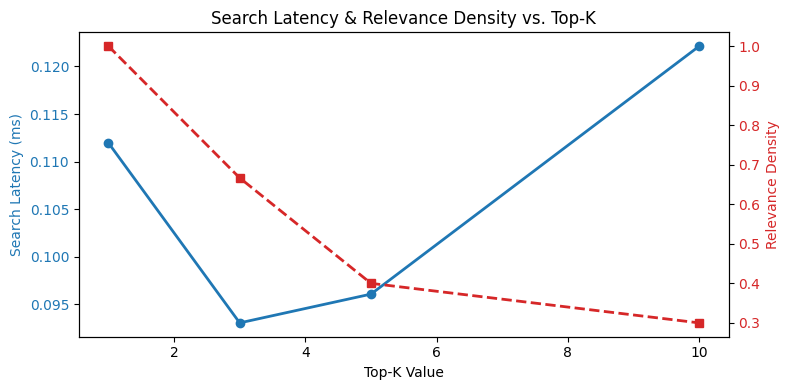

In [7]:
import faiss

db_model_name = "BGE-Small"
model_data = embedding_benchmarks[db_model_name]
db_embeddings = model_data["embeddings"].copy()
dimension = model_data["dimension"]
search_model = model_data["raw_model"]

faiss.normalize_L2(db_embeddings)


flat_index = faiss.IndexFlatIP(dimension)
flat_index.add(db_embeddings)
print(f"Flat Index (IndexFlatIP) initialized with {flat_index.ntotal} vectors.")

nlist = 5
quantizer = faiss.IndexFlatIP(dimension)
ivf_index = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_INNER_PRODUCT)

ivf_index.train(db_embeddings)
ivf_index.add(db_embeddings)

ivf_index.nprobe = 2

print(f"IVF Index (IndexIVFFlat) trained and initialized with {ivf_index.ntotal} vectors.")

def semantic_search(query, index, model, top_k=3, prefix=""):
    query_text = f"{prefix}{query}"

    start_embed = time.perf_counter()
    query_emb = model.encode([query_text], convert_to_numpy=True)
    faiss.normalize_L2(query_emb)
    end_embed = time.perf_counter()
    embed_latency_ms = (end_embed - start_embed) * 1000


    start_search = time.perf_counter()
    scores, indices = index.search(query_emb, top_k)
    end_search = time.perf_counter()
    search_latency_ms = (end_search - start_search) * 1000

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
        if idx != -1:
            results.append({
                "rank": rank + 1,
                "score": float(score),
                "chunk": primary_chunks[idx]
            })

    return results, {
        "embed_latency_ms": embed_latency_ms,
        "search_latency_ms": search_latency_ms,
        "total_latency_ms": embed_latency_ms + search_latency_ms
    }
test_query = "What is the policy for carrying forward unused leaves?"
flat_results, flat_times = semantic_search(test_query, flat_index, search_model, top_k=3)
ivf_results, ivf_times = semantic_search(test_query, ivf_index, search_model, top_k=3)

print(f"\nQuery: '{test_query}'")
print(f"Flat Index Search Latency: {flat_times['search_latency_ms']:.4f} ms")
print(f"IVF Index Search Latency: {ivf_times['search_latency_ms']:.4f} ms")

print("\nRetrieved Chunks (Flat Index):")
for r in flat_results:
    print(f" - Rank {r['rank']} [Score: {r['score']:.4f}]: '{r['chunk']['text'][:80]}...' (Doc ID: {r['chunk']['doc_id']})")

top_k_values = [1, 3, 5, 10]
top_k_metrics = []

target_doc = "doc_hr_01"

for k in top_k_values:
    results, times = semantic_search(test_query, flat_index, search_model, top_k=k)
    matches = sum(1 for r in results if r["chunk"]["doc_id"] == target_doc)
    relevance_density = matches / k

    top_k_metrics.append({
        "Top-K": k,
        "Search Latency (ms)": times["search_latency_ms"],
        "Total Latency (ms)": times["total_latency_ms"],
        "Target Chunks Retrieved": matches,
        "Relevance Density": relevance_density
    })

df_top_k = pd.DataFrame(top_k_metrics)
print("\n=== Top-K Retrieval Performance Table ===")
print(df_top_k.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8, 4))

color = 'tab:blue'
ax1.set_xlabel('Top-K Value')
ax1.set_ylabel('Search Latency (ms)', color=color)
ax1.plot(df_top_k["Top-K"], df_top_k["Search Latency (ms)"], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Relevance Density', color=color)
ax2.plot(df_top_k["Top-K"], df_top_k["Relevance Density"], marker='s', color=color, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Search Latency & Relevance Density vs. Top-K")
fig.tight_layout()
plt.show()


In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("=== Loading TinyLlama-1.1B-Chat-v1.0 in 4-bit ===")
get_vram_usage()

device_map = "auto" if torch.cuda.is_available() else "cpu"

llm_tokenizer = AutoTokenizer.from_pretrained(model_id)
llm_tokenizer.pad_token = llm_tokenizer.eos_token
if torch.cuda.is_available():
    llm_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config_4bit,
        device_map=device_map
    )
else:
    llm_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="cpu"
    )

print("\nModel loaded successfully.")
get_vram_usage()

def generate_llm_response(prompt, model, tokenizer, max_new_tokens=256, temperature=0.1):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_length = inputs.input_ids.shape[1]

    start_time = time.perf_counter()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True if temperature > 0.0 else False,
            pad_token_id=tokenizer.eos_token_id
        )
    end_time = time.perf_counter()

    generation_latency = end_time - start_time
    generated_tokens = outputs[0][input_length:]
    response_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    num_tokens = len(generated_tokens)
    tokens_per_sec = num_tokens / generation_latency if generation_latency > 0 else 0

    return response_text, {
        "latency_sec": generation_latency,
        "num_tokens": num_tokens,
        "tokens_per_sec": tokens_per_sec
    }

test_prompt = """<|system|>
You are a helpful assistant.</s>
<|user|>
Explain in one sentence what RAG is.</s>
<|assistant|>"""

response, metrics = generate_llm_response(test_prompt, llm_model, llm_tokenizer)
print(f"\nTest Prompt: 'Explain in one sentence what RAG is.'")
print(f"LLM Response: '{response}'")
print(f"Performance: {metrics['tokens_per_sec']:.2f} tokens/sec ({metrics['latency_sec']:.2f}s total)")


=== Loading TinyLlama-1.1B-Chat-v1.0 in 4-bit ===
[VRAM Monitor] CUDA is not active. VRAM tracking unavailable.


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model loaded successfully.
[VRAM Monitor] CUDA is not active. VRAM tracking unavailable.

Test Prompt: 'Explain in one sentence what RAG is.'
LLM Response: '
RAG (Rapid Automated Genetic Algorithm) is a genetic algorithm used for optimization in computer science and engineering. It is a genetic algorithm that is designed to find the best solution to a given problem quickly and efficiently. RAG is a type of genetic algorithm that uses a randomized selection process to find the best solution to a problem. The process involves mutating and crossover operations to create new solutions, which are then evaluated and compared to the current solution. The process continues until a solution is found that meets the desired criteria. RAG is commonly used in optimization problems, such as finding the best route for a vehicle or finding the most efficient way to sort an array of numbers.'
Performance: 1.41 tokens/sec (104.56s total)
